In [12]:
import numpy as np 
import pandas as pd
import re
import random
import nltk
import matplotlib.pyplot as plt
#from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jodya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [13]:
from gensim.models import KeyedVectors

In [14]:
df = pd.read_csv("C:/Users/jodya/Desktop/Programmables/Sem-6/Responsible AI/Assignment-4/train.csv",header = None, names = ['rating','review','title'])
df = df.sample(n=100000,random_state = 42)
df = df.dropna()
df.head()

,rating,review,title
2079998,1,Expensive Junk,This product consists of a piece of thin flexi...
1443106,1,Toast too dark,"Even on the lowest setting, the toast is too d..."
3463669,2,Excellent imagery...dumbed down story,I enjoyed this disc. The video is stunning. I ...
2914699,1,Are we pretending everyone is married?,The authors pretend that parents neither die n...
1603231,1,Not worth your time,"Might as well just use a knife, this product h..."


In [15]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]','',text)
    tokens = text.split()
    return tokens
df['tokens'] = df['review'].apply(preprocess) 
    

In [16]:
import gensim.downloader as api

fasttext = (api.load("fasttext-wiki-news-subwords-300"))
word2vec = (api.load("word2vec-google-news-300"))


  0%|                                                                                      | 0/3000000 [16:41<?, ?it/s]


In [17]:
def get_review_embedding(tokens,model):
    vectors = []
    for word in tokens:
        if word in model:
            vectors.append(model[word])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors,axis=0)
review_embeddings = []
for tokens in df['tokens']:
    review_embeddings.append(get_review_embedding(tokens,fasttext))
review_embeddings = np.array(review_embeddings)

In [18]:
query = "battery life is very poor"
query_tokens = preprocess(query)
query_embeddings = get_review_embedding(query_tokens,fasttext)
similarities = cosine_similarity(
    [query_embeddings],
    review_embeddings
)[0]
top5_idx = np.argsort(similarities)[-5:][::-1]
print("top 5")
for idx in top5_idx:
    print(f"score: {similarities[idx]:.4f}")
    print(df.iloc[idx]['review'])

top 5
score: 1.0000
Battery life is very poor
score: 0.9474
Battery Life is Terrible
score: 0.9430
Avanti Service is very poor
score: 0.9424
fidelity is very poor
score: 0.9349
Sound quality is very poor


In [19]:
def introduce_noise(text, prob=0.2):
    words = text.split()
    noisy_words = []
    for word in words:
        if random.random() < prob and len(word) > 3:
            i = random.randint(0,len(word)-2)
            word = word[:i] + word[i+1] + word[i] + word[i+2:]
        noisy_words.append(word)
    return " ".join(noisy_words)
df['noisy_review'] = df['review'].apply(introduce_noise)
df['noisy_tokens'] = df['noisy_review'].apply(preprocess)

  0%|                                                                                       | 0/999999 [17:43<?, ?it/s]


In [20]:
def get_embeddings_coverage(tokens,model):
    count = 0
    for word in tokens:
        if word in model:
            count +=1
    return count/len(tokens) if len(tokens) > 0 else 0
w2v_coverage = []
ft_coverage = []
for tokens in df['noisy_tokens']:
    w2v_coverage.append(get_embeddings_coverage(tokens,word2vec))
    ft_coverage.append(get_embeddings_coverage(tokens,fasttext))
print("average w2v: ",np.mean(w2v_coverage))
print("average ft: ",np.mean(ft_coverage))

average w2v:  0.7988386677189012
average ft:  0.8745995612347289


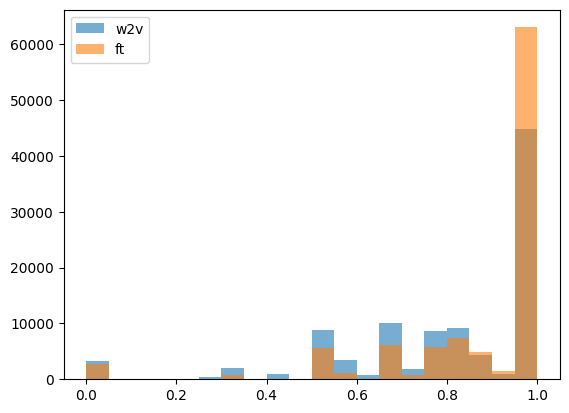

In [21]:
plt.hist(w2v_coverage,bins=20,alpha=0.6,label='w2v')
plt.hist(ft_coverage,bins=20,alpha=0.6,label='ft')
plt.legend()
plt.show()

In [22]:
unique_words = set()
for tokens in df['tokens']:
    unique_words.update(tokens)
unique_words = list(unique_words)
print("total unique words: ", len(unique_words))

total unique words:  31992


In [23]:
w2v_present = 0
ft_present = 0
for word in unique_words:
    if word in word2vec:
        w2v_present += 1
    if word in fasttext:
        ft_present += 1
print("W2V Coverage:", w2v_present / len(unique_words))
print("FT Coverage:", ft_present / len(unique_words))

W2V Coverage: 0.6862965741435358
FT Coverage: 0.7231495373843461
